In [1]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 553.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s eta 0:00:00


Adım 1 da Haber Sinyali: 0
Adım 1 da İşlem Yapan Ajan Sayısı: 0
Adım 2 da Haber Sinyali: 1
Adım 2 da İşlem Yapan Ajan Sayısı: 995
Adım 3 da Haber Sinyali: 1
Adım 3 da İşlem Yapan Ajan Sayısı: 995
Adım 4 da Haber Sinyali: 0
Adım 4 da İşlem Yapan Ajan Sayısı: 995
Adım 5 da Haber Sinyali: -1
Adım 5 da İşlem Yapan Ajan Sayısı: 995
Adım 6 da Haber Sinyali: 1
Adım 6 da İşlem Yapan Ajan Sayısı: 995
Adım 7 da Haber Sinyali: 0
Adım 7 da İşlem Yapan Ajan Sayısı: 995
Adım 8 da Haber Sinyali: -1
Adım 8 da İşlem Yapan Ajan Sayısı: 995
Adım 9 da Haber Sinyali: 1
Adım 9 da İşlem Yapan Ajan Sayısı: 995
Adım 10 da Haber Sinyali: 0
Adım 10 da İşlem Yapan Ajan Sayısı: 995
Adım 11 da Haber Sinyali: 1
Adım 11 da İşlem Yapan Ajan Sayısı: 995
Adım 12 da Haber Sinyali: 1
Adım 12 da İşlem Yapan Ajan Sayısı: 995
Adım 13 da Haber Sinyali: -1
Adım 13 da İşlem Yapan Ajan Sayısı: 995
Adım 14 da Haber Sinyali: -1
Adım 14 da İşlem Yapan Ajan Sayısı: 995
Adım 15 da Haber Sinyali: 0
Adım 15 da İşlem Yapan Ajan Sayısı: 

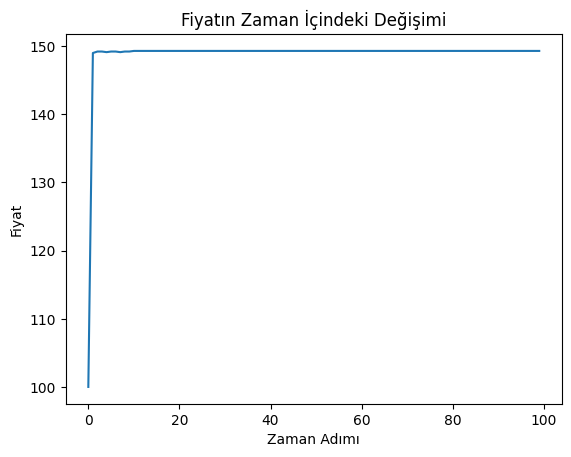

In [158]:
import random


class FundamentalAgent(mesa.Agent):
    """
    Piyasada temel analize göre alım/satım yapan ajan.
    """
    def __init__(self, model):
        super().__init__(model)
        self.cash = 1000
        self.shares = 0
        self.sensitivity = self.random.uniform(0, 1)      # θi: Haber duyarlılığı [0, 1]
        self.risk_tolerance =  self.random.uniform(0, 100) # αi: Risk toleransı (pozisyon değişim miktarını belirler)
        self.position_change_this_step = 0 # Bu adımda gerçekleştirilen pozisyon değişimi (∆qi(t))
        self.islem_yapildi_mi = False # İşlem yapılıp yapılmadığını takip etmek için


    def step(self):
        price = self.model.current_price
        # Modelden güncel haber sinyalini al
        news_signal = self.model.current_news_signal

        # Beklenen pozisyon değişimini hesapla: ∆qi(t) = θi * αi * H(t)
        # Özetinizdeki formülü doğrudan kullanıyoruz.
        # αi'nin pozisyon değişim miktarını belirlediği belirtilmiş.
        # H(t)'nin -1, 0, +1 olması pozisyonun yönünü belirliyor.
        # θi ve αi'nin çarpımı pozisyon değişiminin büyüklüğünü belirler.
        desired_position_change = (self.sensitivity * self.risk_tolerance * news_signal)*(self.cash // price)
        #print(f"Ajan {self.unique_id} için Beklenen Pozisyon Değişikliği: {desired_position_change}") # Yeni raporlama


        actual_position_change = 0

        if desired_position_change > 0:
            # Alım yapmak istiyor

            # Alabileceği maksimum hisse miktarı: cash / price
            max_shares_to_buy = self.cash // price if price > 0 else 0 # Fiyat sıfırsa alım yapamaz

            # Almak istediği miktar (desired_position_change) ondalıklı olabilir.
            # Alabileceği maksimum miktarın minimumu kadar alır, bu da ondalıklı olabilir.
            shares_to_buy_float = min(desired_position_change, max_shares_to_buy)

            # Hisse miktarını tamsayıya yuvarla (örneğin, tabana yuvarla)
            shares_to_buy = int(shares_to_buy_float)

            if shares_to_buy > 0:
                self.islem_yapildi_mi = True
                cost = shares_to_buy * price
                if self.cash >= cost: # Nakit kontrolü
                    self.shares += shares_to_buy
                    self.cash -= cost
                    actual_position_change = shares_to_buy
                # else: Nakit yetersiz, alım yapamaz



        elif desired_position_change < 0:
            # Satış yapmak istiyor
            # Satmak istediği miktar: |desired_position_change| ondalıklı olabilir.
            shares_to_sell_float = abs(desired_position_change)

            # Sahip olduğu hisse miktarı ondalıklı olabilir.
            # Satmak istediği miktarın minimumu kadar satar, bu da ondalıklı olabilir.
            actual_shares_to_sell_float = min(shares_to_sell_float, self.shares)

            # Hisse miktarını tamsayıya yuvarla (örneğin, tavana yuvarla veya en yakına)
            # Burada satılacak hisseyi tamsayı yaparken dikkatli olmak lazım.
            # Elimizde olan hisse sayısını aşmamalı.
            # Basitçe tabana yuvarlayalım ve sonra elimizdeki hisse sayısıyla tekrar min alalım.
            actual_shares_to_sell = int(actual_shares_to_sell_float)
            actual_shares_to_sell = min(actual_shares_to_sell, int(self.shares)) # Elimizdekinden fazla satmamak için tamsayı halini kontrol et


            if actual_shares_to_sell > 0:
                self.islem_yapildi_mi = True
                revenue = actual_shares_to_sell * price
                self.shares -= actual_shares_to_sell
                self.cash += revenue
                actual_position_change = -actual_shares_to_sell # Satış olduğu için negatif

        # Bu adımda gerçekleşen pozisyon değişimini kaydet
        self.position_change_this_step = actual_position_change

    def get_wealth(self):
        # Basit bir varlık hesaplama
        return self.cash + self.shares * self.model.current_price if self.model.current_price > 0 else self.cash


import mesa

class FinancialModel(mesa.Model):
    """
    Temel analiz yapan ajanlardan oluşan bir finans piyasası modeli.
    """
    def __init__(self, num_agents, initial_price, liquidity_lambda):
        super().__init__()
        self.num_agents = num_agents
        self.current_price = initial_price
        self.liquidity_lambda = liquidity_lambda # λ likidite katsayısı

        self.islem_yapan_ajan_sayisi = 0 # Yeni öznitelik




        # Ajanları oluştur
        # self.agentss = [] # Bu satır gereksiz
        for i in range(self.num_agents):
            agent = FundamentalAgent(self)
            self.agents.add(agent)


        # Data Collector ekleyebiliriz (opsiyonel ama kullanışlı)
        self.datacollector = mesa.DataCollector(
            model_reporters={"Price": "current_price",
                             "Net Demand": lambda m: sum([a.position_change_this_step for a in m.agents]), # schedule.agents kullanıldı
                             "Total Shares": lambda m: sum([a.shares for a in m.agents]), # schedule.agents kullanıldı
                             "Total Cash": lambda m: sum([a.cash for a in m.agents]), # schedule.agents kullanıldı
                             "Total Wealth": lambda m: sum([a.get_wealth() for a in m.agents]), # schedule.agents kullanıldı
                             "News Signal": "current_news_signal"},
            agent_reporters={"Cash": lambda a: a.cash,
                             "Shares": lambda a: a.shares,
                             "Wealth": lambda a: a.get_wealth(),
                             "Position Change": lambda a: a.position_change_this_step,
                             "Sensitivity": lambda a: a.sensitivity,
                             "Risk Tolerance": lambda a: a.risk_tolerance
                            }
        )

        self.current_news_signal = 0 # İlk adımda haber sinyali

    def step(self):
        self.islem_yapan_ajan_sayisi = 0 # Yeni adımda islem_yapan_ajan_sayisi sıfırlanır


        # 1. Haber Sinyalini Oluştur
        self.current_news_signal = self.random.choice([-1, 0, 1])
        print(f"Adım {self.steps} da Haber Sinyali: {self.current_news_signal}") # Yeni raporlama

        # 2. Ajanların Adımını Çalıştır (Bu, agent.step() metodunu çağırır ve pozisyon değişimlerini kaydeder)
        # self.agents.do("step") # Bu satırda hata vardı, schedule çalıştırılmalı
        self.agents.do("step")

        # İşlem yapan ajan sayısını hesapla
        # self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi) # Bu satırda hata vardı, schedule.agents kullanıldı
        self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi)

        # print(f"Adım {self.steps} da İşlem Yapan Ajan Sayısı: {self.islem_yapan_ajan_sayisi}") # Yeni raporlama # self.steps yerine self.schedule.steps kullanıldı
        print(f"Adım {self.steps} da İşlem Yapan Ajan Sayısı: {self.islem_yapan_ajan_sayisi}")


        # 3. Toplam Net Talebi Hesapla: Σ ∆qi(t)
        # Her ajanın step metodunda kaydettiği position_change_this_step değerlerini topluyoruz
        # total_net_demand = sum([a.position_change_this_step for a in self.agents]) # Bu satırda hata vardı, schedule.agents kullanıldı
        total_net_demand = sum([a.position_change_this_step for a in self.agents])


        # 4. Fiyatı Güncelle: P(t+1) = P(t) * (1 + λ * (Σ ∆qi(t) / N))
        # İşlem yapan ajan sayısı sıfırsa veya toplam net talep sıfırsa fiyat değişmez
        # total_net_demand'in sıfır olması durumu da eklendi, çünkü 0/N de 0 olur ama
        # islem_yapan_ajan_sayisi 0 iken bölme hatası olmaması için bu kontrol şart.
        if self.islem_yapan_ajan_sayisi > 0:
            price_multiplier = 1 + self.liquidity_lambda * (total_net_demand / self.islem_yapan_ajan_sayisi)
            self.current_price = self.current_price * price_multiplier
        # Else: İşlem yapan ajan yok, fiyat sabit kalır.



        # Fiyatın en az 1 gibi bir alt sınırda kalmasını sağlayabiliriz (opsiyonel, model tanımında yok ama pratik olabilir)
        # self.current_price = max(1.0, self.current_price)


        # Veri Topla (Opsiyonel)
        self.datacollector.collect(self)

# Modelin çalıştırılması için örnek kullanım:
if __name__ == "__main__":
    num_agents = 1000
    initial_price = 100
    liquidity_lambda = 0.05 # Örnek likidite katsayısı
    num_steps = 100

    model = FinancialModel(num_agents, initial_price, liquidity_lambda)

    for i in range(num_steps):
        model.step()

    # Sonuçları incelemek için DataCollector'ı kullanabilirsiniz
    model_data = model.datacollector.get_model_vars_dataframe()
    agent_data = model.datacollector.get_agent_vars_dataframe()

    print("Model Verileri:")
    print(model_data.head(10))

    print("\nAjan Verileri (İlk Adım İçin):")
    print(agent_data.head(10)) # İlk birkaç satırı yazdırmak genellikle daha kullanışlıdır

    # Örnek: Fiyatın zaman içindeki değişimini çizdirebilirsiniz (matplotlib gerektirir)
    try:
        import matplotlib.pyplot as plt
        model_data["Price"].plot(title="Fiyatın Zaman İçindeki Değişimi")
        plt.xlabel("Zaman Adımı")
        plt.ylabel("Fiyat")
        plt.show()
    except ImportError:
        print("Matplotlib yüklü değil. Grafik çizilemedi.")

Simülasyon çıktısında neden her adımda dinamik olarak değişmediği, aynı çıktıyı verdiği sorusunu akla getiriyor.

Bunun olası nedenleri şunlardır:

Tutarlı Haber Sinyali: İlk adımda haber sinyali 0 olabilir (bu durumda kimse işlem yapmaz), ancak 2. adımdan 7. adıma kadar rastgele üretilen haber sinyalinin sürekli olarak ya +1 ya da -1 olması mümkündür. Eğer başlangıç nakitleri, fiyat, ajanların duyarlılıkları ve risk toleransları, 50 ajandan yaklaşık 33'ünün non-zero bir desired_position_change (duyarlılık * risk_toleransı * haber_sinyali) değerine sahip olacak şekilde belirlenmişse (yani işlem yapmak istiyorlarsa) ve en az 1 hisse işlemi yapmak için yeterli nakit/hisseleri varsa, haber sinyali sabit kaldığı sürece işlem yapan ajan sayısı da sabit kalabilir.
Ajan Parametreleri: Ajanların sensitivity ve risk_tolerance değerleri simülasyonun başlangıcında bir kere atanır ve zamanla değişmezler. Eğer 50 ajanınızın büyük bir kısmı (örneğin 33 tanesi), parametrelerinin non-zero bir haber sinyali ile çarpıldığında ve potansiyel olarak nakit/hisse limitleriyle sınırlandırıldığında, sürekli olarak en az bir hisselik bir işlem yapma isteğiyle sonuçlanan kombinasyonlara sahipse, 33 işlem yapan ajan sayısı sabit bir sonuç olabilir.
Tam Sayı Hisse İşlemi: Ajanlar sadece tam sayılarla hisse işlemi yapar (int(shares_to_buy_float) ve int(actual_shares_to_sell_float)). Bu, eğer desired_position_change 0 ile 1 (dahil değil) arasındaysa, tam sayıya çevrildiğinde 0 olacağı ve işlem yapılmayacağı anlamına gelir. Eğer 33 ajanın parametreleri, sürekli olarak 0'dan yeterince uzak desired_position_change değerleri üretiyorsa (alım için tam sayıya çevrilince 1 veya daha fazla, satım için -1 veya daha az), geri kalan ajanların parametreleri ise 0'a yakın değerler üretiyorsa, sabit bir işlem yapan ajan sayısı görmeniz doğaldır.
Fiyat İstikrarı: Eğer bu 33 ajanın işlem aktivitesi çok az net taleple sonuçlanıyorsa veya liquidity_lambda değeri küçükse, fiyat değişimi her adımda ihmal edilebilir olabilir. Sabit bir fiyat, sabit ajan parametreleri ve tutarlı bir non-zero haber sinyali bir araya geldiğinde, her adımda aynı ajan grubunun işlem yapmaya çalışmasına yol açabilir.
Ajan Zenginlik/Envanter Limitleri: Kod, ajanların alım için yeterli nakiti veya satım için yeterli hissesi olup olmadığını kontrol etse de, ajanlar başlangıçta bol kaynakla başlıyorlarsa ve işlemler küçükse, ilk birkaç adımda bu limitlere ulaşamayabilirler, bu da işlem sayısının sabit kalmasına katkıda bulunabilir.
Özetle, "İşlem Yapan Ajan Sayısı"nın sabit kalması, büyük olasılıkla tutarlı bir non-zero haber sinyalinin (2-7. adımlar için rastgele olarak +1 veya -1 seçilmiş olabilir) ve belirli bir grup ajanın (duyarlılık * risk_toleransı * haber_sinyali'nin tam sayı bir işlemle sonuçlandığı ajanlar) sabit parametrelerinin birleşimi sonucunda, ilk adımdan sonraki her adımda aynı ajan alt kümesinin işlem yapmasına yol açtığını göstermektedir. Parametreleri -1 ile 1 (dahil değil) arasında desired_position_change ile sonuçlanan ajanlar işlem yapmayacaktır.

Önerilen Değişiklikler
"İşlem Yapan Ajan Sayısı"nı daha dinamik hale getirmek ve simülasyonu daha iyi anlamak için şunları yapabilirsiniz:

Haber Sinyalini Doğrulayın: FinancialModel içindeki step metodunda her adımda self.current_news_signal değerini yazdırın. Bu, haber sinyalinin ilk adımdan sonra sabit kalıp kalmadığını doğrulamanıza yardımcı olur.
Ajan Parametrelerini İnceleyin: Ajansı başlattıktan sonra bireysel ajanların sensitivity ve risk_tolerance dağılımını inceleyebilirsiniz. DataCollector'a bunları agent_reporters olarak ekleyebilirsiniz.
İstenen Pozisyon Değişikliğini Loglayın: Ajanın step metodu içine, birkaç ajan için desired_position_change değerini yazdıran geçici bir print ifadesi ekleyin. Bu, istenen değişikliklerin sürekli olarak aynı ajan grubu için sıfır olmayan tam sayı işlemleriyle sonuçlanıp sonuçlanmadığını görmenize yardımcı olur.
Ajan Verilerini Analiz Edin: DataCollector'dan toplanan agent_data DataFrame'ini kullanarak her ajanın her adımda yaptığı işlemleri (Position Change) inceleyin. Bu, tam olarak hangi ajanların işlem yaptığını ve ne kadar işlem yaptığını gösterecektir.
Daha Fazla Ajan Heterojenliği Ekleyin: Rastgele sensitivity ve risk_tolerance değerleriniz olsa da, başlangıç nakit/hisseler aynı. Başlangıç kaynaklarına daha fazla varyasyon ekleyebilir veya farklı işlem stratejilerine sahip farklı ajan tipleri oluşturabilirsiniz.
Kesirli Hisseleri Değerlendirin: Eğer tam sayı hisse işlemleri, -1 ile 1 arasındaki birçok istenen işlemin göz ardı edilmesine neden oluyorsa, modeliniz izin veriyorsa kesirli hisselere izin vermeyi düşünün. Bu, işlem kararını 0 etrafındaki tam eşik değerlerine daha az bağımlı hale getirir.
Fiyat ve Varlık Değişimlerini İnceleyin: Price, Total Cash ve Total Shares değerlerinin adımlar boyunca değişip değişmediğini kontrol edin. Eğer değişiyorlarsa, işlemler gerçekleşiyor ve piyasa durumunu etkiliyor demektir, ancak işlem yapan ajanların sayısı sadece bu adımlarda sabit kalmış olabilir.
Sorunu daha etkin bir şekilde gidermek için:

Yukarıdaki kodda bulunan ve haber sinyalini yazdıran yorum satırlarını aktif hale getirin.
İsterseniz ajanların istenen pozisyon değişimlerini yazdıran yorum satırlarını da aktif hale getirin (ancak çok fazla çıktıya neden olabilir).
Güncellenmiş kodu çalıştırın ve çıktıları inceleyin. Model veri tablosundaki "News Signal" sütununa dikkat edin. Eğer haber sinyali 2. adımdan 7. adıma kadar sabitse (+1 veya -1), bu, sabit işlem sayısının önemli bir nedenidir.
Gerekirse agent_data DataFrame'ini inceleyerek, hangi ajanların hangi adımda ne kadar işlem yaptığını detaylıca görün.
Adım 2'den itibaren sabit kalan 33 sayısına dayanarak, haber sinyalinin 2-7. adımlarda non-zero (ya +1 ya da -1) olduğu ve 33 ajanın rastgele parametrelerinin, bu non-zero sinyalle çarpıldığında ve tam sayıya yuvarlandığında, sürekli olarak 1 veya daha fazla (alım için) ya da -1 veya daha az (satım için) bir sonuç veren sensitivity * risk_tolerance ürününe sahip olduğu büyük olasılıkla doğrudur. Geri kalan 17 ajanın parametreleri ise muhtemelen istenen değişimin -1 ile 1 arasında (dahil değil) kalmasına neden olarak tam sayı bir işleme yol açmamıştır.

In [157]:
import random
import mesa
import pandas as pd
import matplotlib.pyplot as plt

class FundamentalAgent(mesa.Agent):
    """
    Piyasada temel analize göre alım/satım yapan ajan.
    """
    def __init__(self, model, initial_cash, initial_shares):
        super().__init__(model)
        self.cash = initial_cash
        # Dikkat: shares float olarak temsil ediliyor, ancak tam sayı olarak işlem görüyor.
        self.shares = float(initial_shares) # Shares başlangıçta float olarak saklanabilir
        self.sensitivity = self.random.uniform(0, 1)      # θi: Haber duyarlılığı [0, 1]
        self.risk_tolerance = self.random.uniform(1, 100) # αi: Risk toleransı (pozisyon değişim miktarını belirler)
        self.position_change_this_step = 0
        self.islem_yapildi_mi = False

    def step(self):
        self.islem_yapildi_mi = False
        self.position_change_this_step = 0 # Adım başında sıfırlama

        news_signal = self.model.current_news_signal
        desired_position_change = (self.sensitivity * self.risk_tolerance * news_signal) * (self.cash // self.model.current_price)

        price = self.model.current_price
        actual_position_change = 0

        # Debugging: İsteyen birkaç ajanın istenen pozisyon değişimini ve kaynak limitlerini yazdır
        # İlk 5 adım ve ilk 3 ajan için detayları görmek faydalı olabilir
        if self.unique_id in [0, 1, 2] and self.model.steps < 5:
             max_buy = self.cash // price if price > 0 else 0
             print(f"  Ajan {self.unique_id} (Step {self.model.steps}): Sens={self.sensitivity:.4f}, RiskTol={self.risk_tolerance:.4f}, News={news_signal}, DesiredChange={desired_position_change:.4f}, Cash={self.cash:.2f}, Shares={self.shares:.2f}, Price={price:.2f}, MaxBuy={max_buy}, int(min(Des,Max))= {int(min(desired_position_change, max_buy)) if desired_position_change > 0 else 'N/A'}, int(min(AbsDes,Sh))= {int(min(abs(desired_position_change), self.shares)) if desired_position_change < 0 else 'N/A'}")


        if desired_position_change > 0:
            max_shares_to_buy = self.cash // price if price > 0 else 0 # Tamsayı olarak alınabilecek max hisse
            # desired_position_change ondalıklı olabilir
            shares_to_buy_float = min(desired_position_change, max_shares_to_buy)
            shares_to_buy = int(shares_to_buy_float) # Tamsayı alım adedi

            if shares_to_buy > 0:
                self.islem_yapildi_mi = True
                cost = shares_to_buy * price
                if self.cash >= cost:
                    self.shares += shares_to_buy # Hisse float artabilir
                    self.cash -= cost
                    actual_position_change = shares_to_buy


        elif desired_position_change < 0:
            shares_to_sell_float = abs(desired_position_change) # ondalıklı olabilir
            # Sahip olunan hisse float olabilir, tamsayı kısmına bakarak satılabilecek max hisse
            max_shares_can_sell = int(self.shares)
            actual_shares_to_sell_float = min(shares_to_sell_float, max_shares_can_sell)
            actual_shares_to_sell = int(actual_shares_to_sell_float) # Tamsayı satım adedi


            if actual_shares_to_sell > 0:
                self.islem_yapildi_mi = True
                revenue = actual_shares_to_sell * price
                self.shares -= actual_shares_to_sell # Hisse float azalabilir
                self.cash += revenue
                actual_position_change = -actual_shares_to_sell # Satış olduğu için negatif

        self.position_change_this_step = actual_position_change

    def get_wealth(self):
        return self.cash + self.shares * self.model.current_price if self.model.current_price > 0 else self.cash


class FinancialModel(mesa.Model):
    """
    Temel analiz yapan ajanlardan oluşan bir finans piyasası modeli.
    """
    def __init__(self, num_agents, initial_price, liquidity_lambda, initial_cash_per_agent=1000, initial_shares_per_agent=0, seed=None):
        super().__init__(seed=seed)
        self.num_agents = num_agents
        self.current_price = initial_price
        self.liquidity_lambda = liquidity_lambda

        self.islem_yapan_ajan_sayisi = 0



        for i in range(self.num_agents):
            agent = FundamentalAgent(

                self,
                initial_cash=initial_cash_per_agent,
                initial_shares=initial_shares_per_agent
            )
            self.agents.add(agent)

        self.datacollector = mesa.DataCollector(
            model_reporters={"Price": "current_price",
                             "Total Shares": lambda m: sum([a.shares for a in m.agents]),
                             "Total Cash": lambda m: sum([a.cash for a in m.agents]),
                             "Total Wealth": lambda m: sum([a.get_wealth() for a in m.agents]),
                             "News Signal": "current_news_signal",
                             "Trading Agents Count": "islem_yapan_ajan_sayisi",
                             "Total Net Demand": lambda m: sum([a.position_change_this_step for a in m.agents])
                             },
            agent_reporters={"Cash": lambda a: a.cash,
                             "Shares": lambda a: a.shares, # Ajanın hisse sayısını float olarak alalım
                             "Wealth": lambda a: a.get_wealth(),
                             "Position Change": lambda a: a.position_change_this_step,
                             "Sensitivity": lambda a: a.sensitivity,
                             "Risk Tolerance": lambda a: a.risk_tolerance
                             }
        )

        self.current_news_signal = 0 # İlk adımda haber sinyali model başlangıcında 0 olarak ayarlanır

    def step(self):
        self.islem_yapan_ajan_sayisi = 0
        for agent in self.agents:
            agent.position_change_this_step = 0
            agent.islem_yapildi_mi = False

        self.current_news_signal = self.random.choice([-1, 0, 1])

        # Debugging: Güncel haber sinyalini yazdır
        print(f"Adım {self.steps}: Haber Sinyali = {self.current_news_signal}")


        self.agents.do("step")

        self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi)

        print(f"Adım {self.steps} da İşlem Yapan Ajan Sayısı: {self.islem_yapan_ajan_sayisi}")


        total_net_demand = sum([a.position_change_this_step for a in self.agents])

        # Fiyat güncelleme formülü
        if self.islem_yapan_ajan_sayisi > 0:
            # Model tanımınızda fiyatta net talebin işlem yapan ajan sayısına oranı kullanılıyor.
            # Eğer tüm ajanlar işlem yapsaydı, bu oran net talebin toplam ajan sayısına oranı olurdu.
            # Mevcut mantığı koruyalım, ancak bu formülün modelin davranışını nasıl etkilediğini düşünmek önemli.
            price_multiplier = 1 + self.liquidity_lambda * (total_net_demand / self.islem_yapan_ajan_sayisi)
            self.current_price = self.current_price * price_multiplier

        # Fiyatın negatif olmaması için bir kontrol eklenebilir
        self.current_price = max(0.01, self.current_price) # Fiyatın en az 0.01 olmasını sağla

        self.datacollector.collect(self)

if __name__ == "__main__":
    num_agents_1 = 100
    num_agents_2 = 1000
    initial_price = 100
    liquidity_lambda = 0.05
    num_steps_to_show = 7 # İlk 7 adımı göster

    model_seed = 4 # Sabit seed kullanarak iki simülasyonu karşılaştırabiliriz

    print(f"Simülasyon Başlıyor: {num_agents_1} Ajan ile, {num_steps_to_show} Adım (Seed: {model_seed})")
    print("-" * 30)
    model_1 = FinancialModel(num_agents_1, initial_price, liquidity_lambda, seed=model_seed)
    for i in range(num_steps_to_show):
        model_1.step()
    print("-" * 30)
    model_data_1 = model_1.datacollector.get_model_vars_dataframe()
    print(f"\n{num_agents_1} Ajan İçin İlk {num_steps_to_show} Adım Model Verileri:")
    print(model_data_1.head(num_steps_to_show))


    print(f"\n\nSimülasyon Başlıyor: {num_agents_2} Ajan ile, {num_steps_to_show} Adım (Seed: {model_seed})")
    print("-" * 30)
    # Aynı seed ile yeni bir model oluşturarak agent random değerlerinin farklı örneklerini görebiliriz
    # Aynı seed kullanmak, Mesa'nın random sayı üretecini aynı başlangıç durumuna getirir.
    # Ancak 1000 ajan olması, 100 ajana göre daha fazla random sayı üretimi ve farklı bir sıra demektir.
    # Bu yüzden aynı seed ile bile farklı ajan parametreleri ve haber sinyali sıraları oluşabilir.
    model_2 = FinancialModel(num_agents_2, initial_price, liquidity_lambda, seed=model_seed)
    for i in range(num_steps_to_show):
        model_2.step()
    print("-" * 30)
    model_data_2 = model_2.datacollector.get_model_vars_dataframe()
    print(f"\n{num_agents_2} Ajan İçin İlk {num_steps_to_show} Adım Model Verileri:")
    print(model_data_2.head(num_steps_to_show))

    # Ajan verilerini de inceleyerek hangi ajanların ne zaman işlem yaptığını görebilirsiniz
    # agent_data_1 = model_1.datacollector.get_agent_vars_dataframe()
    # agent_data_2 = model_2.datacollector.get_agent_vars_dataframe()
    # print("\n100 Ajan Modelinden İlk Ajan Verileri (Örnek):")
    # print(agent_data_1.head(num_agents_1)) # Tüm 100 ajanın ilk adım verileri
    # print("\n1000 Ajan Modelinden İlk Ajan Verileri (Örnek):")
    # print(agent_data_2.head(num_agents_2)) # Tüm 1000 ajanın ilk adım verileri

    # İşlem yapan ajanları filtreleyerek inceleyebilirsiniz
    # trading_agents_1 = agent_data_1[agent_data_1['Position Change'] != 0]
    # print(f"\n100 Ajan Modelinde İşlem Yapan Ajanların İlk Adım Verileri (Toplam {len(trading_agents_1[trading_agents_1.index.get_level_values('Step') == 0])}):")
    # print(trading_agents_1[trading_agents_1.index.get_level_values('Step') == 0].head())
    #
    # trading_agents_2 = agent_data_2[agent_data_2['Position Change'] != 0]
    # print(f"\n1000 Ajan Modelinde İşlem Yapan Ajanların İlk Adım Verileri (Toplam {len(trading_agents_2[trading_agents_2.index.get_level_values('Step') == 0])}):")
    # print(trading_agents_2[trading_agents_2.index.get_level_values('Step') == 0].head())

Simülasyon Başlıyor: 100 Ajan ile, 7 Adım (Seed: 4)
------------------------------
Adım 1: Haber Sinyali = -1
  Ajan 1 (Step 1): Sens=0.2360, RiskTol=11.2134, News=-1, DesiredChange=-26.4691, Cash=1000.00, Shares=0.00, Price=100.00, MaxBuy=10, int(min(Des,Max))= N/A, int(min(AbsDes,Sh))= 0
  Ajan 2 (Step 1): Sens=0.3961, RiskTol=16.3423, News=-1, DesiredChange=-64.7248, Cash=1000.00, Shares=0.00, Price=100.00, MaxBuy=10, int(min(Des,Max))= N/A, int(min(AbsDes,Sh))= 0
Adım 1 da İşlem Yapan Ajan Sayısı: 0
Adım 2: Haber Sinyali = -1
  Ajan 1 (Step 2): Sens=0.2360, RiskTol=11.2134, News=-1, DesiredChange=-26.4691, Cash=1000.00, Shares=0.00, Price=100.00, MaxBuy=10, int(min(Des,Max))= N/A, int(min(AbsDes,Sh))= 0
  Ajan 2 (Step 2): Sens=0.3961, RiskTol=16.3423, News=-1, DesiredChange=-64.7248, Cash=1000.00, Shares=0.00, Price=100.00, MaxBuy=10, int(min(Des,Max))= N/A, int(min(AbsDes,Sh))= 0
Adım 2 da İşlem Yapan Ajan Sayısı: 0
Adım 3: Haber Sinyali = 0
  Ajan 1 (Step 3): Sens=0.2360, RiskTol

Simülasyon Başlıyor: 50 Ajan ile, 100 Adım (Seed: 42)
------------------------------
------------------------------
Simülasyon Bitti.

İlk 100 Adım İçin Model Verileri:
         Price  Total Shares    Total Cash  Total Wealth  News Signal  \
0   100.000000           0.0  50000.000000  50000.000000           -1   
1   147.900000         479.0   2100.000000  72944.100000            1   
2   155.295000         483.0   1508.400000  76515.885000            1   
3   147.530250         481.0   1818.990000  72781.040250           -1   
4   154.906763         484.0   1376.399250  76351.272300            1   
..         ...           ...           ...           ...          ...   
95  162.652101         486.0   1066.585725  80115.506629           -1   
96  162.652101         486.0   1066.585725  80115.506629            1   
97  162.652101         486.0   1066.585725  80115.506629           -1   
98  162.652101         486.0   1066.585725  80115.506629            0   
99  162.652101         486.0

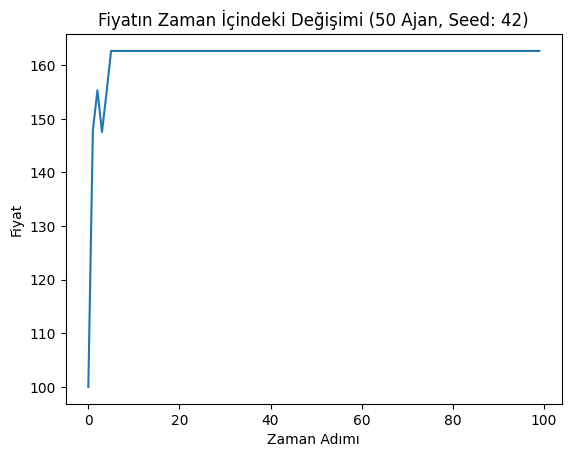

In [156]:
import random

import matplotlib.pyplot as plt

class FundamentalAgent(mesa.Agent):
    """
    Piyasada temel analize göre alım/satım yapan ajan.
    """
    def __init__(self, model, initial_cash, initial_shares):
        super().__init__(model)
        self.cash = initial_cash
        self.shares = float(initial_shares)
        self.sensitivity = self.random.uniform(0, 1)      # θi: Haber duyarlılığı [0, 1]
        self.risk_tolerance = self.random.uniform(0, 100) # αi: Risk toleransı (pozisyon değişim miktarını belirler)
        self.position_change_this_step = 0
        self.islem_yapildi_mi = False

    def step(self):
        self.islem_yapildi_mi = False
        self.position_change_this_step = 0 # Adım başında sıfırlama

        news_signal = self.model.current_news_signal
        price = self.model.current_price

        # Başarılı olan değişiklik: desired_position_change hesaplaması
        # Haber sinyalinin yönü ve ajanın duyarlılığı/risk toleransı ile
        # mevcut nakitleriyle alabilecekleri maksimum tam sayı hisse sayısını çarparak istenen pozisyon değişimini hesapla
        # Fiyat 0 veya negatifse (gerçekçi olmasa da modelde kontrol önemli), alım gücü 0'dır.
        max_shares_from_cash = self.cash // price if price > 0 else 0

        # İstenen pozisyon değişimi: (duyarlılık * risk toleransı * haber sinyali) * (nakit ile alınabilecek tam sayı hisse)
        # Haber sinyali -1 ise bu değer negatif olacaktır (satım isteği)
        # Haber sinyali +1 ise bu değer pozitif olacaktır (alım isteği)
        # Haber sinyali 0 ise bu değer 0 olacaktır (işlem yok)
        # Bu hesaplama artık ajanın alım gücüne bağlı olarak istenen miktarı ölçekliyor.
        desired_position_change = (self.sensitivity * self.risk_tolerance * news_signal) * max_shares_from_cash

        actual_position_change = 0

        # Debugging: İsteyen birkaç ajanın istenen pozisyon değişimini ve kaynak limitlerini yazdır
        # İlk 5 adım ve ilk 3 ajan için detayları görmek faydalı olabilir
        # if self.unique_id in [0, 1, 2] and self.model.schedule.steps < 5:
        #      max_buy = self.cash // price if price > 0 else 0
        #      print(f"  Ajan {self.unique_id} (Step {self.model.schedule.steps}): Sens={self.sensitivity:.4f}, RiskTol={self.risk_tolerance:.4f}, News={news_signal}, DesiredChange={desired_position_change:.4f}, Cash={self.cash:.2f}, Shares={self.shares:.2f}, Price={price:.2f}, MaxBuy={max_buy}, int(min(Des,Max))= {int(min(desired_position_change, max_buy)) if desired_position_change > 0 else 'N/A'}, int(min(AbsDes,Sh))= {int(min(abs(desired_position_change), self.shares)) if desired_position_change < 0 else 'N/A'}")


        if desired_position_change > 0:
            # Alım yapmak istiyor

            # desired_position_change artık zaten nakit ile alabilecek maksimum tam sayı hisse sayısı (max_shares_from_cash)
            # ile ölçeklendi. Yani bu değer, teorik olarak almak istediği toplam hisse sayısı (nakit limitine göre ölçeklenmiş).
            # min(desired_position_change, max_shares_from_cash) kontrolü teknik olarak gereksiz
            # çünkü desired_position_change zaten max_shares_from_cash'in bir oranı (veya 0) olarak hesaplandı
            # ve pozitifse asla max_shares_from_cash'i aşamaz.
            # Ancak floating point hassasiyeti veya mantıksal netlik için tutulabilir,
            # veya sadece desired_position_change'in tam sayı kısmını alabilirsiniz.
            # Şimdilik sizin orijinal mantığınızı koruyalım (min alıp sonra int yapmak).

            shares_to_buy_float = min(desired_position_change, max_shares_from_cash) # Zaten max_shares_from_cash ile ölçeklenmiş olsa da min tekrar almak güvenli olabilir
            shares_to_buy = int(shares_to_buy_float) # Tamsayı alım adedi

            # Yine de nakit kontrolü yapalım, floating point hatalarına karşı veya mantık farklıysa.
            if shares_to_buy > 0:
                self.islem_yapildi_mi = True
                cost = shares_to_buy * price
                if self.cash >= cost: # Nakit kontrolü
                    self.shares += shares_to_buy # Hisse float artabilir
                    self.cash -= cost
                    actual_position_change = shares_to_buy


        elif desired_position_change < 0:
            # Satış yapmak istiyor
            # İstenen satım miktarı: |desired_position_change| ondalıklı olabilir.
            # Bu değer (self.sensitivity * self.risk_tolerance * abs(news_signal)) * max_shares_from_cash'e eşittir.
            shares_to_sell_float = abs(desired_position_change)

            # Satabileceği maksimum miktar, sahip olduğu hisse sayısı ile sınırlıdır.
            max_shares_can_sell = int(self.shares) # Sahip olunan hissenin tam sayı kısmı
            actual_shares_to_sell_float = min(shares_to_sell_float, max_shares_can_sell)
            actual_shares_to_sell = int(actual_shares_to_sell_float) # Tamsayı satım adedi

            # Elimizdekinden fazla satmamak için son bir kontrol
            actual_shares_to_sell = min(actual_shares_to_sell, int(self.shares))


            if actual_shares_to_sell > 0:
                self.islem_yapildi_mi = True
                revenue = actual_shares_to_sell * price
                self.shares -= actual_shares_to_sell # Hisse float azalabilir
                self.cash += revenue
                actual_position_change = -actual_shares_to_sell # Satış olduğu için negatif

        self.position_change_this_step = actual_position_change

    def get_wealth(self):
        # Basit bir varlık hesaplama
        # Fiyat sıfırsa sadece nakiti varlık olarak kabul et
        return self.cash + self.shares * self.model.current_price if self.model.current_price > 0 else self.cash


class FinancialModel(mesa.Model):
    """
    Temel analiz yapan ajanlardan oluşan bir finans piyasası modeli.
    """
    def __init__(self, num_agents, initial_price, liquidity_lambda, initial_cash_per_agent=1000, initial_shares_per_agent=0, seed=None):
        super().__init__(seed=seed)
        self.num_agents = num_agents
        self.current_price = initial_price
        self.liquidity_lambda = liquidity_lambda

        self.islem_yapan_ajan_sayisi = 0


        for i in range(self.num_agents):
            agent = FundamentalAgent(

                self,
                initial_cash=initial_cash_per_agent,
                initial_shares=initial_shares_per_agent
            )
            self.agents.add(agent)



        self.datacollector = mesa.DataCollector(
            model_reporters={"Price": "current_price",
                             "Total Shares": lambda m: sum([a.shares for a in m.agents]),
                             "Total Cash": lambda m: sum([a.cash for a in m.agents]),
                             "Total Wealth": lambda m: sum([a.get_wealth() for a in m.agents]),
                             "News Signal": "current_news_signal",
                             "Trading Agents Count": "islem_yapan_ajan_sayisi",
                             "Total Net Demand": lambda m: sum([a.position_change_this_step for a in m.agents])
                             },
            agent_reporters={"Cash": lambda a: a.cash,
                             "Shares": lambda a: a.shares,
                             "Wealth": lambda a: a.get_wealth(),
                             "Position Change": lambda a: a.position_change_this_step,
                             "Sensitivity": lambda a: a.sensitivity,
                             "Risk Tolerance": lambda a: a.risk_tolerance
                             }
        )

        self.current_news_signal = 0 # İlk adımda haber sinyali model başlangıcında 0 olarak ayarlanır

    def step(self):
        self.islem_yapan_ajan_sayisi = 0
        for agent in self.agents:
            agent.position_change_this_step = 0
            agent.islem_yapildi_mi = False

        self.current_news_signal = self.random.choice([-1, 0, 1])

        # Debugging: Güncel haber sinyalini yazdır
        # print(f"Adım {self.schedule.steps}: Haber Sinyali = {self.current_news_signal}")

        self.agents.do("step") # Ajanların step metodunu çalıştırır

        # Ajan adımları tamamlandıktan sonra işlem yapan ajan sayısını hesapla
        self.islem_yapan_ajan_sayisi = sum(1 for a in self.agents if a.islem_yapildi_mi)

        # İşlem yapan ajan sayısını yazdır (eğer isterseniz)
        # print(f"Adım {self.schedule.steps} da İşlem Yapan Ajan Sayısı: {self.islem_yapan_ajan_sayisi}")

        # Toplam Net Talebi Hesapla
        total_net_demand = sum([a.position_change_this_step for a in self.agents])

        # Fiyatı Güncelle
        # İşlem yapan ajan sayısı 0 ise bölme hatası olmaması için kontrol
        if self.islem_yapan_ajan_sayisi > 0:
            # Fiyat güncelleme formülü: P(t+1) = P(t) * (1 + λ * (Σ ∆qi(t) / N_trading))
            price_multiplier = 1 + self.liquidity_lambda * (total_net_demand / self.islem_yapan_ajan_sayisi)
            self.current_price = self.current_price * price_multiplier

        # Fiyatın negatif olmaması için basit bir kontrol
        self.current_price = max(0.01, self.current_price)

        # Veri Topla
        self.datacollector.collect(self)

# Modelin çalıştırılması için örnek kullanım:
if __name__ == "__main__":
    num_agents_to_run = 50 # Test etmek istediğiniz ajan sayısını buraya girin (örneğin 50, 100, 1000)
    initial_price = 100
    liquidity_lambda = 0.05
    num_steps_to_run = 100 # Göstermek istediğiniz adım sayısını buraya girin

    model_seed = 42 # Tekrarlanabilirlik için seed

    print(f"Simülasyon Başlıyor: {num_agents_to_run} Ajan ile, {num_steps_to_run} Adım (Seed: {model_seed})")
    print("-" * 30)

    model = FinancialModel(num_agents_to_run, initial_price, liquidity_lambda, seed=model_seed)

    for i in range(num_steps_to_run):
        model.step()

    print("-" * 30)
    print("Simülasyon Bitti.")

    # İlk istenen sayıda adım için model verilerini al ve yazdır
    model_data = model.datacollector.get_model_vars_dataframe()
    print(f"\nİlk {num_steps_to_run} Adım İçin Model Verileri:")
    print(model_data.head(num_steps_to_run))

    # İsterseniz ajan verilerini de inceleyebilirsiniz
    # agent_data = model.datacollector.get_agent_vars_dataframe()
    # print("\nAjan Verileri (İlk Adımlar İçin Örnek):")
    # print(agent_data.head(num_agents_to_run * num_steps_to_run)) # Tüm adımlar ve ajanlar için

    # Grafik çizme (isteğe bağlı)
    try:
        model_data["Price"].plot(title=f"Fiyatın Zaman İçindeki Değişimi ({num_agents_to_run} Ajan, Seed: {model_seed})")
        plt.xlabel("Zaman Adımı")
        plt.ylabel("Fiyat")
        plt.show()
    except ImportError:
        print("Matplotlib yüklü değil. Grafik çizilemedi.")